In [1]:
pip install ultralytics gradio opencv-python pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.5 MB/s eta 0:00:00


In [2]:
import gradio as gr
from ultralytics import YOLO
import PIL.Image as Image
import cv2
import numpy as np

# 1. LOAD MODEL YOLOv8
# Kita gunakan versi 'nano' (yolov8n) agar ringan dan cepat saat dideploy
model = YOLO('yolov8n.pt')

def detect_inventory(img):
    if img is None:
        return None, "Silakan unggah gambar."

    # 2. PROSES DETEKSI
    # Kita arahkan model untuk mendeteksi benda-benda umum di gudang (bottle, box, dsb)
    results = model(img)

    # Ambil hasil gambar yang sudah diberi kotak (bounding boxes)
    res_plotted = results[0].plot()

    # 3. ANALISIS JUMLAH BARANG
    # Menghitung berapa banyak objek yang terdeteksi
    detections = results[0].boxes.cls.tolist()
    names = model.names

    summary = "### 📦 Hasil Inventarisasi Visual:\n"
    counts = {}
    for class_id in detections:
        name = names[int(class_id)]
        counts[name] = counts.get(name, 0) + 1

    if not counts:
        summary += "Tidak ada barang terdeteksi."
    else:
        for item, count in counts.items():
            summary += f"- **{item.capitalize()}**: {count} unit\n"

    return res_plotted, summary

# 4. ANTARMUKA GRADIO
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    <h1 style='text-align: center;'>📦 IntelliStock AI: Visual Inventory</h1>
    <p style='text-align: center;'>Unggah foto rak gudang Anda untuk menghitung stok secara otomatis menggunakan Computer Vision.</p>
    """)

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="numpy", label="Upload Foto Rak/Barang")
            btn = gr.Button("🔍 Scan Stok", variant="primary")

        with gr.Column():
            output_img = gr.Image(label="Hasil Deteksi Visual")
            output_text = gr.Markdown(label="Ringkasan Stok")

    btn.click(fn=detect_inventory, inputs=input_img, outputs=[output_img, output_text])

if __name__ == "__main__":
    demo.launch()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/tmp/ipykernel_652/2147410351.py:42: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://72780adc3c4ef63ed2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


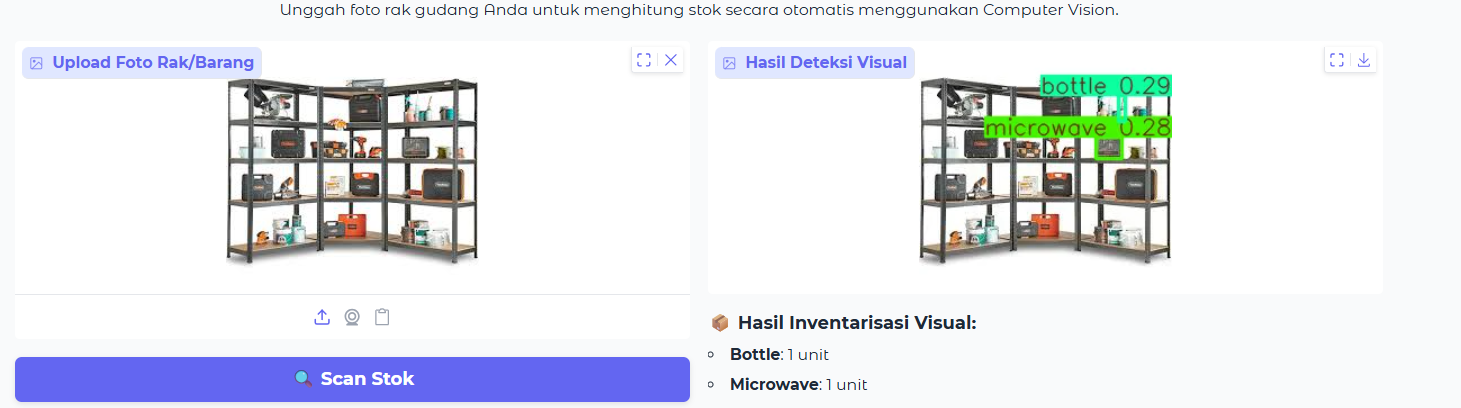

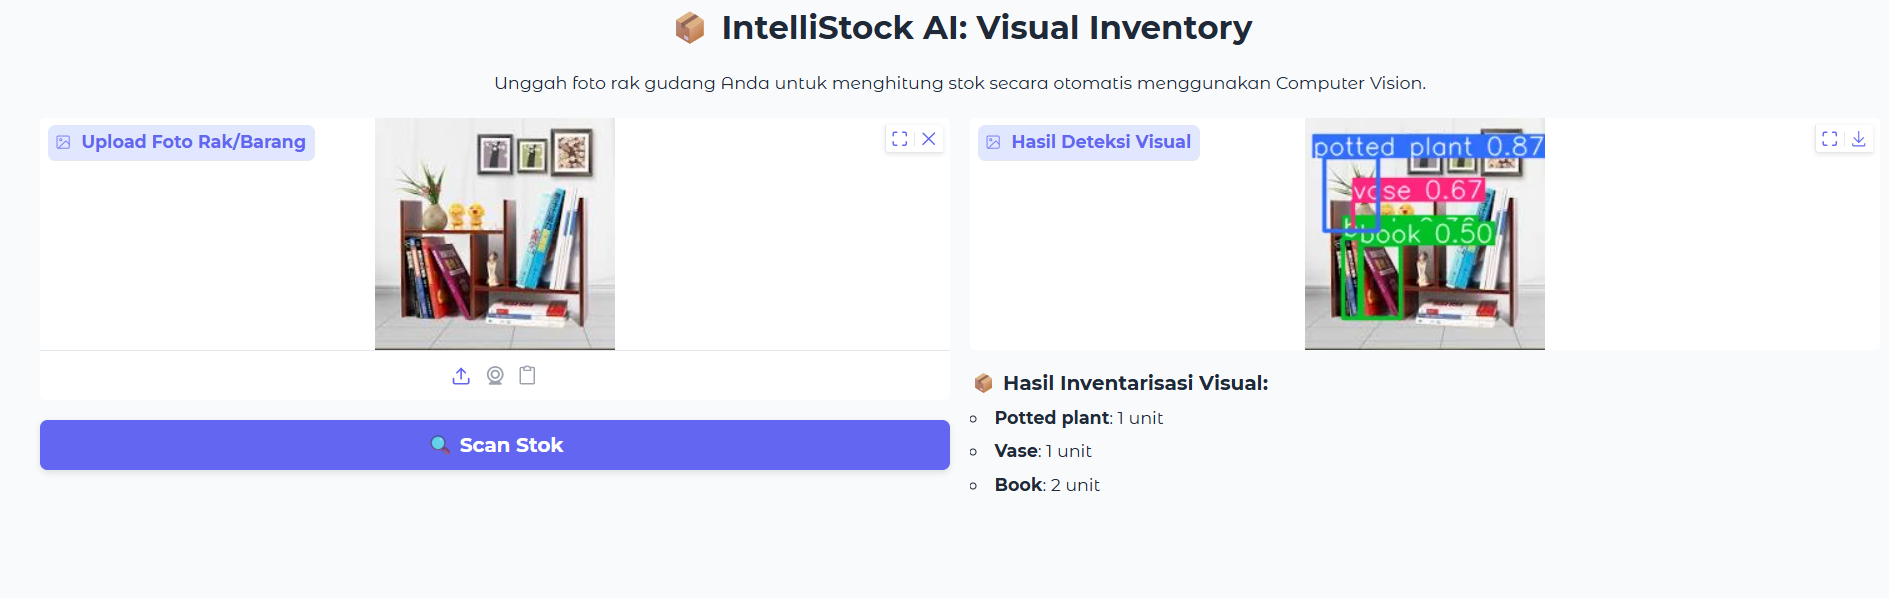